# cic-ids2017 — offline benchmark (RandomForest vs XGBoost, GPU)
public benchmark on **CIC-IDS2017** (abluva/CIC-IDS-2017-V2), 40k balanced rows,
**78 flow features**. two strong tabular models compared; XGBoost trains on the RTX 3070.
note: this is the *offline* benchmark — the board runs our own 6-feature model (`train.ipynb`).

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score)
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('cic_slice.csv').replace([np.inf,-np.inf], np.nan).fillna(0)
FEATURES = [c for c in df.columns if c != 'label']
print('rows', len(df), '| features', len(FEATURES))
print(df['label'].value_counts().to_string())

rows 40000 | features 78
label
bruteforce    8000
flood         8000
normal        8000
scan          8000
slowloris     8000


## detect GPU + prepare data

In [2]:
try:
    xgb.XGBClassifier(n_estimators=2, tree_method='hist', device='cuda').fit(
        np.zeros((4,2),'float32'), [0,1,0,1])
    DEVICE = 'cuda'
except Exception as e:
    DEVICE = 'cpu'; print('no gpu:', str(e)[:80])
print('xgboost device:', DEVICE)

X = df[FEATURES].to_numpy(dtype=float)
le = LabelEncoder().fit(df['label'].astype(str).to_numpy())
y = le.transform(df['label'].astype(str).to_numpy())
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print('train', Xtr.shape, ' test', Xte.shape, ' classes', list(le.classes_))

xgboost device: cuda
train (28000, 78)  test (12000, 78)  classes ['bruteforce', 'flood', 'normal', 'scan', 'slowloris']


## head-to-head — RandomForest (16 cores) vs XGBoost (gpu)

In [3]:
t = time.time()
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0).fit(Xtr, ytr)
rf_t = time.time()-t; rf_acc = accuracy_score(yte, rf.predict(Xte))

t = time.time()
xg = xgb.XGBClassifier(n_estimators=300, tree_method='hist', device=DEVICE, random_state=0).fit(Xtr, ytr)
xg_t = time.time()-t; xg_acc = accuracy_score(yte, xg.predict(Xte))

print(f'RandomForest : acc {rf_acc:.4f}   train {rf_t:5.1f}s  (16 cpu cores)')
print(f'XGBoost      : acc {xg_acc:.4f}   train {xg_t:5.1f}s  ({DEVICE})')

RandomForest : acc 0.9977   train   0.9s  (16 cpu cores)
XGBoost      : acc 0.9988   train   1.4s  (cuda)


## XGBoost — trees vs accuracy

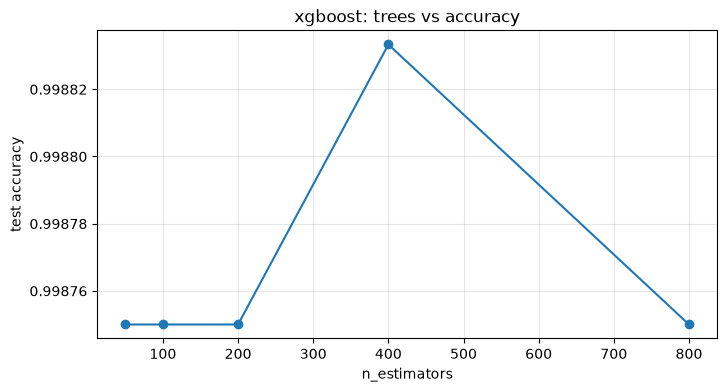

accuracies: [0.9988, 0.9988, 0.9988, 0.9988, 0.9988]


In [4]:
sizes = [50, 100, 200, 400, 800]; acc = []
for n in sizes:
    m = xgb.XGBClassifier(n_estimators=n, tree_method='hist', device=DEVICE, random_state=0).fit(Xtr, ytr)
    acc.append(accuracy_score(yte, m.predict(Xte)))
plt.figure(figsize=(8,4)); plt.plot(sizes, acc, marker='o')
plt.xlabel('n_estimators'); plt.ylabel('test accuracy'); plt.grid(alpha=.3)
plt.title('xgboost: trees vs accuracy'); plt.show()
print('accuracies:', [round(a,4) for a in acc])

## best model (XGBoost) — report + confusion matrix

XGBoost test accuracy: 0.9988
              precision    recall  f1-score   support

  bruteforce       1.00      1.00      1.00      2400
       flood       1.00      1.00      1.00      2400
      normal       1.00      1.00      1.00      2400
        scan       1.00      1.00      1.00      2400
   slowloris       1.00      1.00      1.00      2400

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



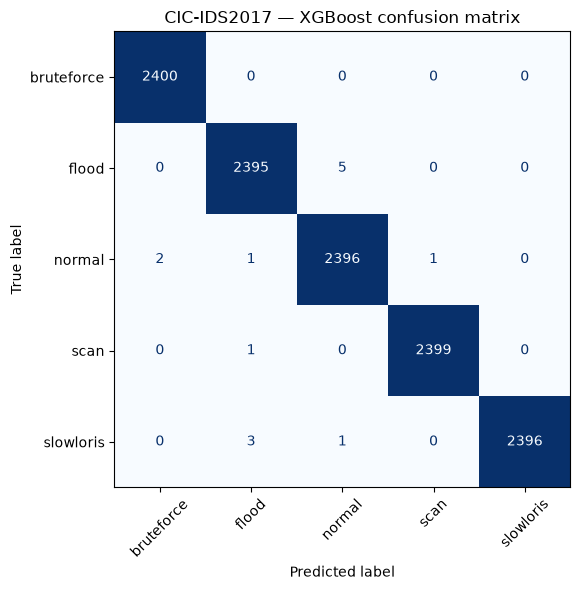

In [5]:
pred = xg.predict(Xte)
print('XGBoost test accuracy:', round(accuracy_score(yte, pred), 4))
print(classification_report(yte, pred, target_names=le.classes_))
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix(yte, pred),
    display_labels=le.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('CIC-IDS2017 — XGBoost confusion matrix'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

## which flow features drive it (XGBoost importance)

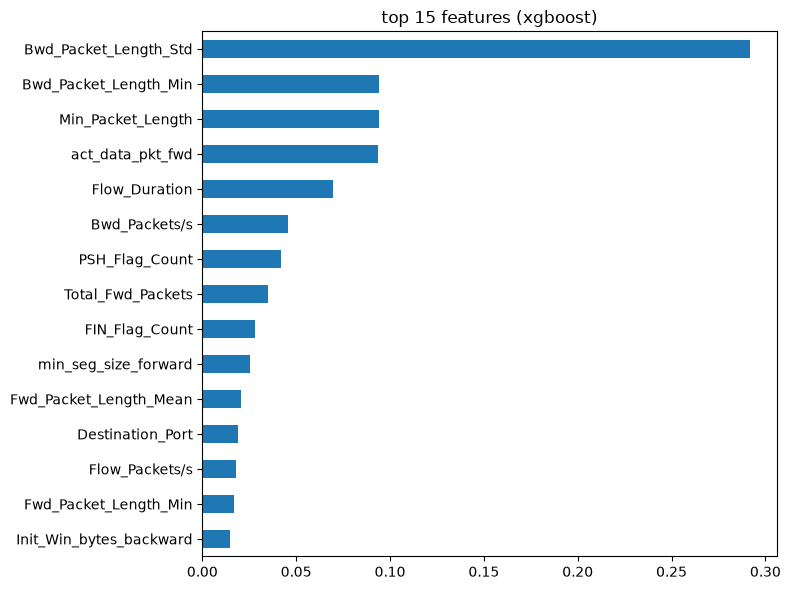

In [6]:
imp = pd.Series(xg.feature_importances_, index=FEATURES).sort_values()[-15:]
plt.figure(figsize=(8,6)); imp.plot.barh()
plt.title('top 15 features (xgboost)'); plt.tight_layout(); plt.show()

## takeaway
- **XGBoost** on CIC-IDS2017 (78 flow features, 40k rows) — the strong public benchmark,
  trained on the **RTX 3070**; compared head-to-head with RandomForest above.
- these 78 flow features can't be computed live on the board, so the **on-board model
  stays our 6-feature one** (`train.ipynb`). benchmark = credibility; small model = the edge.